# Classification de déchets avec PySpark MLlib

Ce notebook montre comment entraîner un modèle de Machine Learning pour identifier le type de déchet à partir de vos images préalablement traitées par `data_processing.py`.

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Initialiser la session Spark
spark = SparkSession.builder \
    .appName("GarbageClassificationML") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark

### Chargement et formatage des données
MLlib nécessite que les features soient sous forme de `Vector`. Nos pixels sont stockés au format texte dans le CSV, séparés par des virgules.

In [8]:
# 2. Préparation des données sans Python UDF (100% Spark SQL)
from pyspark.sql.functions import split, transform
from pyspark.ml.functions import array_to_vector

# 3. Fonction pour charger les CSV et préparer les colonnes
def load_and_prepare_data(path):
    # On utilise quote/escape pour lire correctement la colonne pixels
    df = spark.read.csv(path, header=True, inferSchema=True, quote='\"', escape='\"')

    # Conversion label -> double (requis en MLlib)
    # Conversion pixels (string "1,2,3,...") -> array<double> -> vector
    pixels_array = transform(split(col("pixels"), ","), lambda x: x.cast("double"))

    df = (
        df.withColumn("label", col("label").cast(DoubleType()))
          .withColumn("features", array_to_vector(pixels_array))
    )

    # Supprimer les lignes invalides
    return df.select("label", "features").dropna()

# Charger les jeux d'entraînement et de test
print("Chargement des données...")
train_data = load_and_prepare_data("out_csv/train")
test_data = load_and_prepare_data("out_csv/test")

train_data.show(5)
train_data.printSchema()

Chargement des données...


+-----+--------------------+
|label|            features|
+-----+--------------------+
|  1.0|[229.0,242.0,242....|
|  1.0|[131.0,130.0,114....|
|  1.0|[210.0,220.0,211....|
|  1.0|[94.0,114.0,107.0...|
|  1.0|[184.0,203.0,209....|
+-----+--------------------+
only showing top 5 rows

root
 |-- label: double (nullable = true)
 |-- features: vector (nullable = true)



In [10]:
import os
from datetime import datetime
import numpy as np
import tensorflow as tf
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# --- 1. PRÉPARATION DES DONNÉES (Optimisé PySpark) ---

def preparer_donnees_pyspark(df):
    """
    Réalise le casting et la normalisation côté cluster Spark.
    On suppose que les pixels sont entre 0 et 255.
    """
    return df.select(
        col("label").cast("int").alias("label"),
        # On divise par 255.0 directement dans Spark pour distribuer le calcul
        (vector_to_array("features") / 255.0).alias("pixels_normalises")
    )

def convertir_vers_numpy(df_spark):
    """Convertit le DataFrame Spark préparé en matrices NumPy pour TensorFlow."""
    pdf = df_spark.toPandas()
    # vstack transforme une liste de listes en une matrice (N, pixels)
    X = np.vstack(pdf["pixels_normalises"].values).astype("float32")
    y = pdf["label"].to_numpy(dtype=np.int32)
    return X, y

# --- 2. ARCHITECTURE DU MODÈLE ---



def bloc_residuel(x, nb_filtres, foulée=1):
    """Un bloc ResNet qui aide à éviter la disparition du gradient."""
    raccourci = x
    
    # Première convolution
    x = tf.keras.layers.Conv2D(nb_filtres, 3, strides=foulée, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Deuxième convolution
    x = tf.keras.layers.Conv2D(nb_filtres, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Ajustement du raccourci si la taille change (stride > 1)
    if foulée != 1 or raccourci.shape[-1] != nb_filtres:
        raccourci = tf.keras.layers.Conv2D(nb_filtres, 1, strides=foulée, padding="same", use_bias=False)(raccourci)
        raccourci = tf.keras.layers.BatchNormalization()(raccourci)

    x = tf.keras.layers.Add()([x, raccourci])
    x = tf.keras.layers.ReLU()(x)
    return x

def construire_resnet(input_shape, nb_classes):
    """Construit un modèle ResNet adapté aux images en niveaux de gris."""
    entrees = tf.keras.Input(shape=input_shape)
    
    # Augmentation de données intégrée au modèle
    x = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
    ], name="augmentation")(entrees)

    x = tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Empilement de blocs
    x = bloc_residuel(x, 32, foulée=1)
    x = bloc_residuel(x, 64, foulée=2) # Réduction de taille spatiale
    x = bloc_residuel(x, 128, foulée=2)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    sorties = tf.keras.layers.Dense(nb_classes, activation="softmax")(x)

    return tf.keras.Model(entrees, sorties, name="ResNet_Grayscale")

# --- 3. PIPELINE D'EXÉCUTION ---

# Transformation Spark distribuée
train_prepa = preparer_donnees_pyspark(train_data).cache()
test_prepa = preparer_donnees_pyspark(test_data).cache()

# Split Train/Validation
train_df, val_df = train_prepa.randomSplit([0.9, 0.1], seed=42)

# Conversion NumPy pour Keras
X_train, y_train = convertir_vers_numpy(train_df)
X_val, y_val = convertir_vers_numpy(val_df)
X_test, y_test = convertir_vers_numpy(test_prepa)

# Redimensionnement auto (ex: 784 -> 28x28)
nb_pixels = X_train.shape[1]
cote = int(np.sqrt(nb_pixels))
X_train = X_train.reshape(-1, cote, cote, 1)
X_val = X_val.reshape(-1, cote, cote, 1)
X_test = X_test.reshape(-1, cote, cote, 1)

# Compilation
modele = construire_resnet((cote, cote, 1), int(y_train.max() + 1))
modele.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Callbacks
rappels = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

# Entraînement
print("Début de l'entraînement...")
modele.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=rappels)

# Évaluation
score = modele.evaluate(X_test, y_test, verbose=0)
print(f"Précision finale sur Test : {score[1]*100:.2f}%")

AnalysisException: [DATATYPE_MISMATCH.BINARY_OP_DIFF_TYPES] Cannot resolve "(UDF(features) / 255.0)" due to data type mismatch: the left and right operands of the binary operator have incompatible types ("ARRAY<DOUBLE>" and "DOUBLE").;
'Project [cast(label#537 as int) AS label#601, (UDF(features#541) / 255.0) AS pixels_normalises#602]
+- Filter atleastnnonnulls(2, label#537, features#541)
   +- Project [label#537, features#541]
      +- Project [label#537, pixels#534, UDF(transform(split(pixels#534, ,, -1), lambdafunction(cast(lambda x_2#542 as double), lambda x_2#542, false))) AS features#541]
         +- Project [cast(label#533 as double) AS label#537, pixels#534]
            +- Relation [label#533,pixels#534] csv


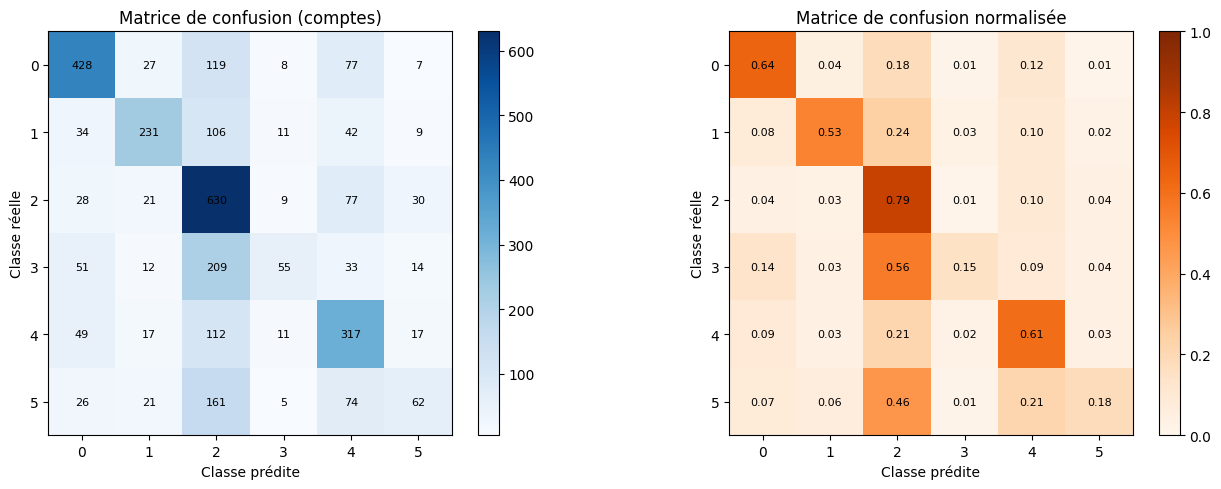

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if "cm" not in globals() or "cm_norm" not in globals():
    raise RuntimeError("Les matrices 'cm' et 'cm_norm' ne sont pas définies. Exécute d'abord la cellule d'entraînement (cellule 6).")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Matrice de confusion (comptes)")
axes[0].set_xlabel("Classe prédite")
axes[0].set_ylabel("Classe réelle")
axes[0].set_xticks(np.arange(cm.shape[1]))
axes[0].set_yticks(np.arange(cm.shape[0]))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cm_norm, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Matrice de confusion normalisée")
axes[1].set_xlabel("Classe prédite")
axes[1].set_ylabel("Classe réelle")
axes[1].set_xticks(np.arange(cm_norm.shape[1]))
axes[1].set_yticks(np.arange(cm_norm.shape[0]))

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()